#Result comparison

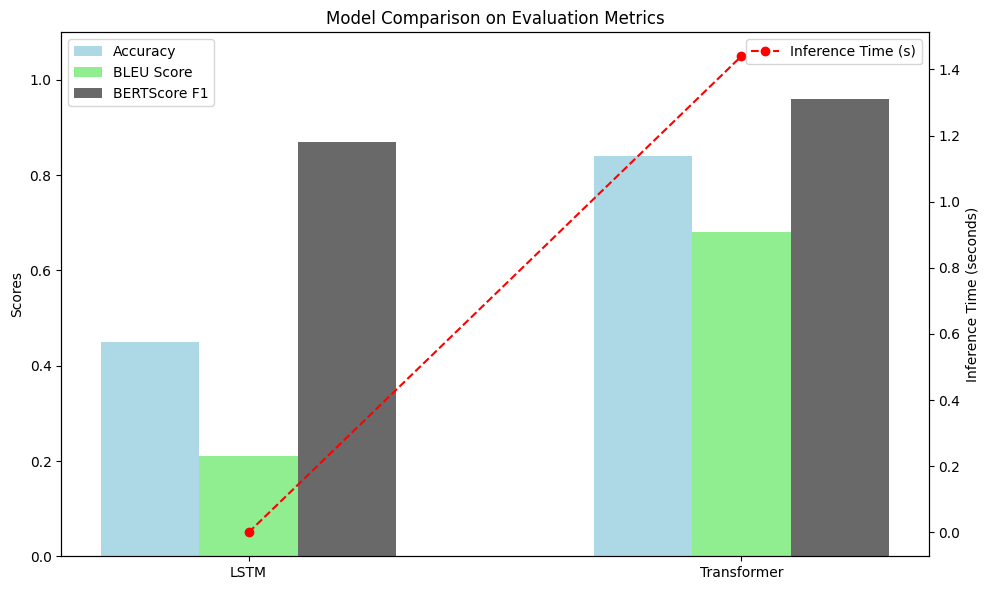

In [23]:
import matplotlib.pyplot as plt
import numpy as np

# Hardcoded evaluation metrics
models = ['LSTM', 'Transformer']
accuracy = [0.45, 0.84]
bleu = [0.21, 0.68]
bertscore_f1 = [0.87, 0.96]
inference_time = [0.0, 1.44]

# Set bar width and positions
x = np.arange(len(models))
width = 0.2

fig, ax1 = plt.subplots(figsize=(10,6))

# Plot Accuracy, BLEU, BERTScore
# set colors also

rects1 = ax1.bar(x - width, accuracy, width, label='Accuracy', color = 'lightblue')
rects2 = ax1.bar(x, bleu, width, label='BLEU Score', color = 'lightgreen')
rects3 = ax1.bar(x + width, bertscore_f1, width, label='BERTScore F1', color='dimgray')

ax1.set_ylabel('Scores')
ax1.set_title('Model Comparison on Evaluation Metrics')
ax1.set_xticks(x)
ax1.set_xticklabels(models)
ax1.set_ylim(0, 1.1)
ax1.legend(loc='upper left')

# Plot Inference Time on secondary y-axis
ax2 = ax1.twinx()
ax2.plot(models, inference_time, color='red', marker='o', linestyle='--', label='Inference Time (s)')
ax2.set_ylabel('Inference Time (seconds)')
ax2.legend(loc='upper right')

# Display the plot
plt.tight_layout()
plt.show()


In [19]:
import ast
import numpy as np

lstm_output_path = "/content/LSTM_test_output.txt"
transformer_output_path = "/content/Transformers_test_output.txt"

# Function to load metrics from the file
def load_metrics(file_path):
    with open(file_path, 'r') as f:
        # Read the file and convert string representation of list/dict to Python object
        data = ast.literal_eval(f.read())

    # Extract metrics into separate lists
    exact_match = [item['ExactMatch'] for item in data]
    bleu = [item['BLEU'] for item in data]
    time_taken = [item['TimeTaken'] for item in data]

    # Convert lists to numpy arrays
    return np.array(exact_match), np.array(bleu), np.array(time_taken)

# Load LSTM metrics
exact_lstm, bleu_lstm, time_lstm = load_metrics(lstm_output_path)

# Load Transformer metrics
exact_transformer, bleu_transformer, time_transformer = load_metrics(transformer_output_path)

# Verify shapes
print("LSTM ExactMatch:", exact_lstm.shape)
print("Transformer ExactMatch:", exact_transformer.shape)
print("LSTM ExactMatch:", bleu_lstm.shape)
print("Transformer ExactMatch:", bleu_lstm.shape)
print("LSTM ExactMatch:", time_lstm.shape)
print("Transformer ExactMatch:", time_lstm.shape)


LSTM ExactMatch: (172,)
Transformer ExactMatch: (172,)
LSTM ExactMatch: (172,)
Transformer ExactMatch: (172,)
LSTM ExactMatch: (172,)
Transformer ExactMatch: (172,)


In [20]:
print("LSTM ExactMatch:", exact_lstm.shape)
print("Transformer ExactMatch:", exact_transformer.shape)
print("LSTM bleu:", bleu_lstm.shape)
print("Transformer bleu:", bleu_transformer.shape)
print("LSTM time:", time_lstm.shape)
print("Transformer time:", time_transformer.shape)

LSTM ExactMatch: (172,)
Transformer ExactMatch: (172,)
LSTM bleu: (172,)
Transformer bleu: (172,)
LSTM time: (172,)
Transformer time: (172,)



--- Exact Match ---
Normality p-value (Shapiro): 0.0000
 => Differences NOT normally distributed: using Wilcoxon signed-rank test
Wilcoxon p-value = 0.0000

--- BLEU ---
Normality p-value (Shapiro): 0.0000
 => Differences NOT normally distributed: using Wilcoxon signed-rank test
Wilcoxon p-value = 0.0000

--- Inference Time ---
Normality p-value (Shapiro): 0.0000
 => Differences NOT normally distributed: using Wilcoxon signed-rank test
Wilcoxon p-value = 0.0000


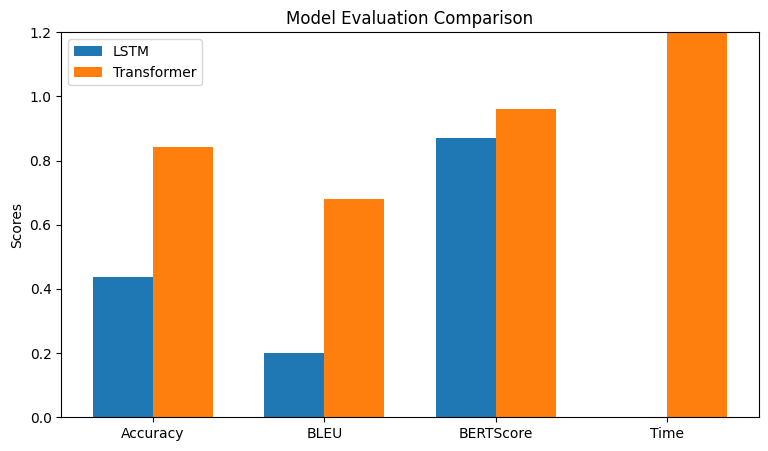

In [22]:
import ast
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_rel, wilcoxon, shapiro

lstm_output_path = "/content/LSTM_test_output.txt"
transformer_output_path = "/content/Transformers_test_output.txt"


def load_metrics(file_path):
    with open(file_path, "r") as f:
        data = ast.literal_eval(f.read())
    exact_match = np.array([item["ExactMatch"] for item in data])
    bleu        = np.array([item["BLEU"] for item in data])
    time_taken  = np.array([item["TimeTaken"] for item in data])
    return exact_match, bleu, time_taken


exact_lstm, bleu_lstm, time_lstm = load_metrics(lstm_output_path)
exact_trf, bleu_trf, time_trf    = load_metrics(transformer_output_path)


def check_and_test(a, b, metric_name):
    diff = a - b
    stat_normal, p_normal = shapiro(diff)
    print(f"\n--- {metric_name} ---")
    print(f"Normality p-value (Shapiro): {p_normal:.4f}")

    if p_normal > 0.05:
        print(" => Differences are normally distributed: using paired t-test")
        t_stat, p_val = ttest_rel(a, b)
        print(f"t-test p-value = {p_val:.4f}")
    else:
        print(" => Differences NOT normally distributed: using Wilcoxon signed-rank test")
        w_stat, p_val = wilcoxon(a, b)
        print(f"Wilcoxon p-value = {p_val:.4f}")


check_and_test(exact_trf, exact_lstm, "Exact Match")
check_and_test(bleu_trf, bleu_lstm, "BLEU")
check_and_test(time_trf, time_lstm, "Inference Time")


labels = ['Accuracy', 'BLEU', 'BERTScore', 'Time']
avg_lstm = [exact_lstm.mean(), bleu_lstm.mean(), 0.87, time_lstm.mean()]
avg_trf  = [exact_trf.mean(),  bleu_trf.mean(),  0.96, time_trf.mean()]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(9,5))
rects1 = ax.bar(x - width/2, avg_lstm, width, label='LSTM')
rects2 = ax.bar(x + width/2, avg_trf,  width, label='Transformer')

ax.set_ylabel('Scores')
ax.set_title('Model Evaluation Comparison')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

plt.ylim(0,1.2)
plt.show()
